In [11]:
# Core
import pandas as pd
import numpy as np

# Splitting
from sklearn.model_selection import train_test_split

# Torch
import torch
from torch.utils.data import Dataset, DataLoader

# TF-IDF (Model 1)
from sklearn.feature_extraction.text import TfidfVectorizer

# LSTM (Model 2)
from collections import Counter

# Transformer (Model 3)
import torch.hub

In [12]:
data = pd.read_csv("amazon_cells_labelled_LARGE_25K.txt", delimiter='\t', header=None)
data.columns = ['Sentence', 'Class']

# Basic cleaning ONLY (safe for all models)
data['Sentence'] = data['Sentence'].astype(str).str.strip()

texts = data['Sentence'].tolist()
labels = data['Class'].tolist()

In [13]:
# First split: train + temp
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

# Second split: validation + test
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42
)

print("Train:", len(train_texts))
print("Validation:", len(val_texts))
print("Test:", len(test_texts))

Train: 20000
Validation: 2500
Test: 2500


# Task 1.2

In [14]:
#Load Tokenizer + Model

from transformers import BertTokenizer, BertForSequenceClassification

# Load tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Load model
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [15]:
#Tokenize training data
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors='pt'  # PyTorch tensors directly
)

# Tokenize validation data
val_encodings = tokenizer(
    val_texts,
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors='pt'
)

# Tokenize test data
test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors='pt'
)

In [16]:
#Dataset Class

class TransformerDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

In [17]:
#Create Dataset + DataLoader

train_dataset = TransformerDataset(train_encodings, train_labels)
val_dataset = TransformerDataset(val_encodings, val_labels)
test_dataset = TransformerDataset(test_encodings, test_labels)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

In [19]:
#training loop

import matplotlib.pyplot as plt

train_losses = []
val_losses = []

epochs = 10

for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss
        total_train_loss += loss.item()

        loss.backward()
        optimizer.step()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation loss
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            total_val_loss += outputs.loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Val Loss={avg_val_loss:.4f}")

Epoch 1: Train Loss=0.2337, Val Loss=0.1800
Epoch 2: Train Loss=0.1356, Val Loss=0.1791
Epoch 3: Train Loss=0.0832, Val Loss=0.2129
Epoch 4: Train Loss=0.0535, Val Loss=0.2321
Epoch 5: Train Loss=0.0351, Val Loss=0.3097
Epoch 6: Train Loss=0.0282, Val Loss=0.3457
Epoch 7: Train Loss=0.0213, Val Loss=0.3415
Epoch 8: Train Loss=0.0172, Val Loss=0.3317
Epoch 9: Train Loss=0.0149, Val Loss=0.3406
Epoch 10: Train Loss=0.0128, Val Loss=0.3259


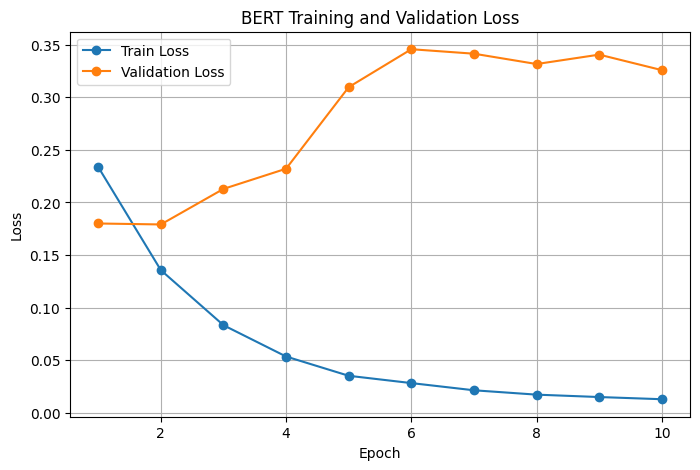

In [20]:
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, epochs+1), val_losses, label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('BERT Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [21]:
#Validation Evaluation

from sklearn.metrics import accuracy_score, classification_report

model.eval()

val_preds = []
val_true = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        preds = torch.argmax(logits, dim=1)

        val_preds.extend(preds.cpu().numpy())
        val_true.extend(labels.cpu().numpy())

print("Validation Accuracy:", accuracy_score(val_true, val_preds))
print(classification_report(val_true, val_preds))

Validation Accuracy: 0.9328
              precision    recall  f1-score   support

           0       0.91      0.92      0.91       961
           1       0.95      0.94      0.95      1539

    accuracy                           0.93      2500
   macro avg       0.93      0.93      0.93      2500
weighted avg       0.93      0.93      0.93      2500



In [22]:
#Test Evaluation (Final Results)

model.eval()

test_preds = []
test_true = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        preds = torch.argmax(logits, dim=1)

        test_preds.extend(preds.cpu().numpy())
        test_true.extend(labels.cpu().numpy())

print("Test Accuracy:", accuracy_score(test_true, test_preds))
print(classification_report(test_true, test_preds))

Test Accuracy: 0.9348
              precision    recall  f1-score   support

           0       0.92      0.91      0.91       965
           1       0.94      0.95      0.95      1535

    accuracy                           0.93      2500
   macro avg       0.93      0.93      0.93      2500
weighted avg       0.93      0.93      0.93      2500



With a larger dataset, the transformer model demonstrates stable convergence and improved generalization. However, overfitting still occurs after a few epochs, indicating that even with more data, careful regularization and early stopping remain important.